# Existing solution reproduction

Source:
"Why Humans Pick One AI Answer Over Another" by starkhushi, Kaggle.

This notebook reproduces and analyzes an existing solution for the
LLM Classification Finetuning competition.

Changes made for the project:
- adapted file paths for local execution;
- added/standardized validation evaluation where necessary;
- added explanations and experiment tracking.

# Why Humans Pick One AI Answer Over Another

**A complete walkthrough of the LLM Classification Finetuning competition** — EDA, preprocessing,
feature engineering, modeling, and a submission — told as one story: *what actually makes a person
prefer one chatbot response to another?*

The data: **57,477 real Chatbot Arena battles.** A user asked a question, two anonymous LLMs answered,
the user picked a winner (or called a tie). Our job: predict that verdict from the text alone,
scored by **log loss** over three outcomes.

### Contents
1. [Meet the arena](#arena)
2. [The target: who wins?](#target)
3. [Bias #1 — verbosity is (almost) destiny](#verbosity)
4. [Bias #2 — refusals are poison](#refusals)
5. [Bias #3 — formatting wins](#formatting)
6. [Where ties live](#ties)
7. [The trap: a great feature you can't use](#trap)
8. [From insights to features](#features)
9. [Models, honestly cross-validated](#models)
10. [Submission](#submission)
11. [Takeaways](#takeaways)

*If this notebook teaches you something, an upvote helps it reach others learning the same things.*

<a id="arena"></a>
## 1. Meet the arena

Each row is one battle. `prompt`, `response_a`, `response_b` are JSON-encoded **lists** — conversations
can have multiple turns — so the very first preprocessing step is parsing them into plain text.

In [2]:
import os, glob, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from pathlib import Path

DATA_DIR = Path("../data/raw")

tr = pd.read_csv(DATA_DIR / "train.csv")
te = pd.read_csv(DATA_DIR / "test.csv")

def parse(s):
    try:
        return ' '.join(x or '' for x in json.loads(s))
    except Exception:
        return str(s)

for col in ['prompt', 'response_a', 'response_b']:
    tr[col + '_txt'] = tr[col].map(parse)
    te[col + '_txt'] = te[col].map(parse)

tr['target'] = np.select([tr.winner_model_a == 1, tr.winner_model_b == 1], ['A wins', 'B wins'], 'Tie')
y = np.select([tr.winner_model_a == 1, tr.winner_model_b == 1], [0, 1], 2)

print(f'{len(tr):,} battles | {tr.model_a.nunique()} distinct models | test rows visible: {len(te)}')
tr[['prompt_txt', 'response_a_txt', 'response_b_txt', 'target']].head(2)

57,477 battles | 64 distinct models | test rows visible: 3


,prompt_txt,response_a_txt,response_b_txt,target
0,Is it morally right to try to have a certain p...,The question of whether it is morally right to...,"As an AI, I don't have personal beliefs or opi...",A wins
1,What is the difference between marriage licens...,A marriage license is a legal document that al...,A marriage license and a marriage certificate ...,B wins


In [3]:
# one consistent visual language for the whole notebook:
# BLUE = response A, ORANGE = response B, GRAY = tie
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#c3c2b7'

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'axes.axisbelow': True,
})

def finish(ax, title, ygrid=True):
    ax.set_title(title, loc='left', pad=12)
    ax.grid(axis='y' if ygrid else 'x', color=GRID, lw=0.8)
    ax.grid(visible=False, axis='x' if ygrid else 'y')
    ax.tick_params(length=0)

<a id="target"></a>
## 2. The target: who wins?

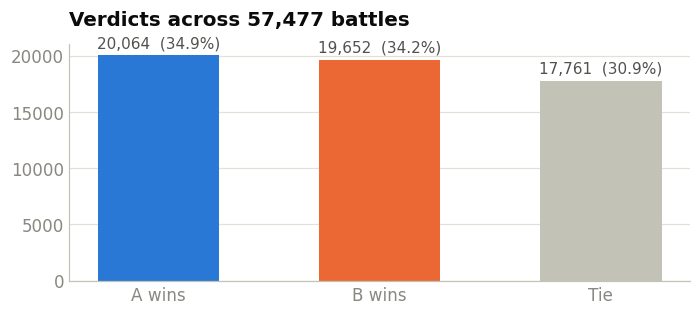

In [4]:
counts = tr['target'].value_counts().reindex(['A wins', 'B wins', 'Tie'])
fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.bar(counts.index, counts.values, color=[BLUE, ORANGE, GRAY], width=0.55)
ax.bar_label(bars, labels=[f'{v:,}  ({v/len(tr):.1%})' for v in counts.values],
             padding=3, color=INK2, fontsize=10)
finish(ax, 'Verdicts across 57,477 battles')
plt.tight_layout(); plt.show()

Three nearly balanced classes — so **uniform guessing scores log loss 1.0986**, and predicting the
class priors barely improves it (1.0972). That's our floor. Note the slight edge for position A
(34.9% vs 34.2%): humans read top-to-bottom, and the first answer enjoys a tiny primacy bias.

Everything below is a hunt for signals that move probabilities away from ⅓/⅓/⅓ — *without* seeing
which model wrote which answer.

<a id="verbosity"></a>
## 3. Bias #1 — verbosity is (almost) destiny

The single most famous finding about human preference data: **people reward longer answers.**

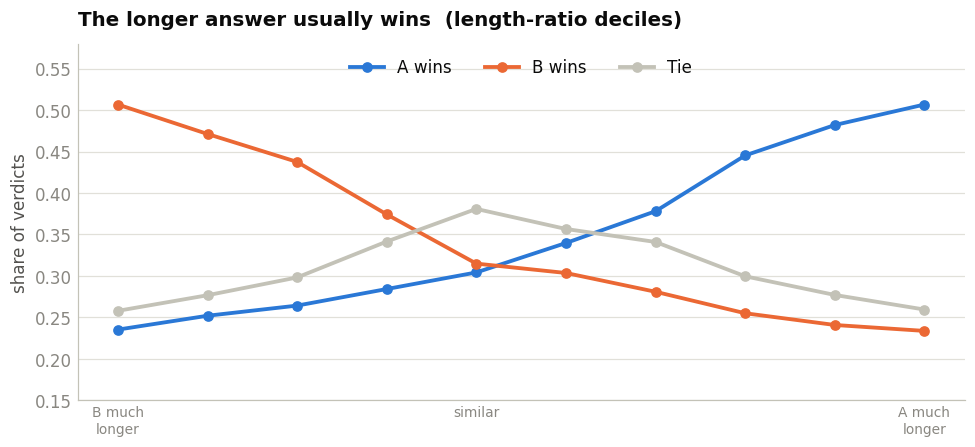

most lopsided decile (A much longer): A wins 50.7%, B wins 23.4%


In [5]:
tr['len_a'] = tr.response_a_txt.str.len()
tr['len_b'] = tr.response_b_txt.str.len()
tr['len_ratio'] = np.log1p(tr.len_a) - np.log1p(tr.len_b)

dec = pd.qcut(tr.len_ratio, 10, duplicates='drop')
g = tr.groupby(dec, observed=True)['target'].value_counts(normalize=True).unstack()
xs = range(len(g))

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(xs, g['A wins'], color=BLUE, lw=2.5, marker='o', ms=6, label='A wins')
ax.plot(xs, g['B wins'], color=ORANGE, lw=2.5, marker='o', ms=6, label='B wins')
ax.plot(xs, g['Tie'], color=GRAY, lw=2.5, marker='o', ms=6, label='Tie')
ax.set_xticks(list(xs), ['B much\nlonger', '', '', '', 'similar', '', '', '', '', 'A much\nlonger'], fontsize=9)
ax.set_ylabel('share of verdicts')
ax.legend(frameon=False, loc='upper center', ncol=3)
ax.set_ylim(0.15, 0.58)
finish(ax, 'The longer answer usually wins  (length-ratio deciles)')
plt.tight_layout(); plt.show()

lop = g.iloc[-1]
print(f"most lopsided decile (A much longer): A wins {lop['A wins']:.1%}, B wins {lop['B wins']:.1%}")

In the extreme decile the longer answer wins **51% vs 23%** — a judge who reads *nothing but the
lengths* already beats random soundly. Two honest caveats worth telling:

- This is partly **quality confounded with length**: stronger models tend to write richer answers.
  The bias and the quality signal travel together, and a text model can't fully separate them.
- The curve is smooth and monotonic — perfect for a model, worrying for humanity.

<a id="refusals"></a>
## 4. Bias #2 — refusals are poison

What happens when exactly one answer opens with *"I'm sorry, I cannot..."*?

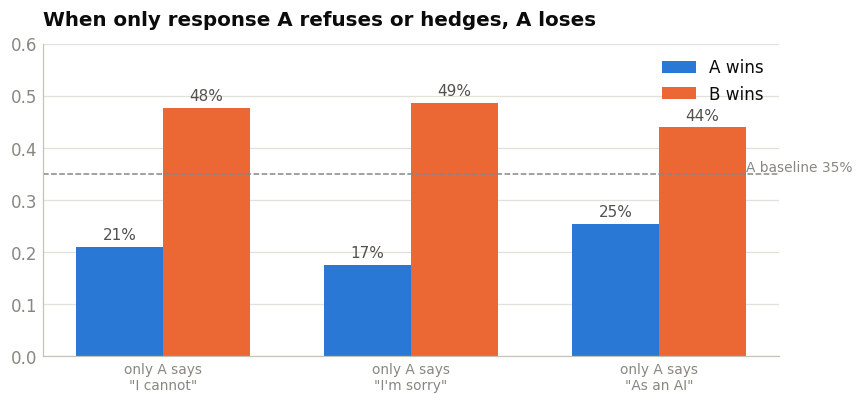

In [6]:
REFUSAL_PHRASES = ['I cannot', "I'm sorry", 'As an AI']
rows = []
for phrase in REFUSAL_PHRASES:
    has_a = tr.response_a_txt.str.contains(phrase, case=False, na=False)
    has_b = tr.response_b_txt.str.contains(phrase, case=False, na=False)
    only_a = has_a & ~has_b
    sub = tr[only_a]
    rows.append({'phrase': f'only A says\n"{phrase}"', 'A wins': (sub.target == 'A wins').mean(),
                 'B wins': (sub.target == 'B wins').mean(), 'n': len(sub)})
ref = pd.DataFrame(rows)

x = np.arange(len(ref)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 3.8))
b1 = ax.bar(x - w/2, ref['A wins'], w, color=BLUE, label='A wins')
b2 = ax.bar(x + w/2, ref['B wins'], w, color=ORANGE, label='B wins')
ax.bar_label(b1, labels=[f'{v:.0%}' for v in ref['A wins']], padding=3, color=INK2, fontsize=10)
ax.bar_label(b2, labels=[f'{v:.0%}' for v in ref['B wins']], padding=3, color=INK2, fontsize=10)
ax.axhline(0.349, color=MUTED, ls='--', lw=1)
ax.text(2.35, 0.355, 'A baseline 35%', color=MUTED, fontsize=9)
ax.set_xticks(x, ref['phrase'], fontsize=9)
ax.set_ylim(0, 0.6)
ax.legend(frameon=False)
finish(ax, 'When only response A refuses or hedges, A loses')
plt.tight_layout(); plt.show()

A response that says *"I'm sorry"* while its rival just answers drops from a 35% baseline to a
**17.5% win rate** — the single strongest lexical signal in the dataset. Safety language, apologies,
and "As an AI" disclaimers all read as *failure to help*. (The effect is symmetric for B.)

<a id="formatting"></a>
## 5. Bias #3 — formatting wins

Bullet lists, headers, **bold** — do cosmetics move verdicts?

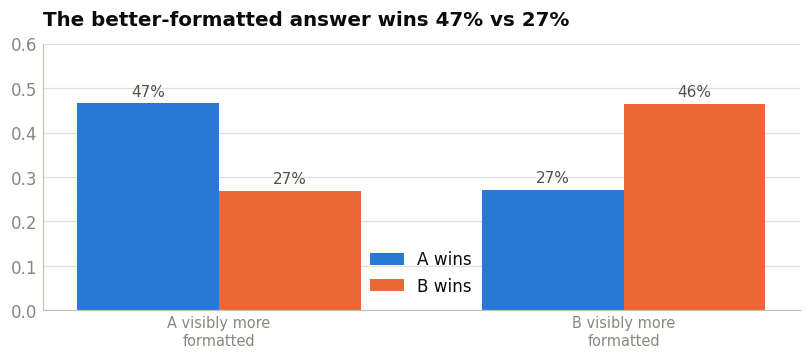

n = 10,985 / 11,071


In [7]:
MD_PAT = r'\n[*#-]|\n\d+\.|\*\*'
tr['md_a'] = tr.response_a_txt.str.count(MD_PAT)
tr['md_b'] = tr.response_b_txt.str.count(MD_PAT)
more_a = tr[tr.md_a > tr.md_b + 2]
more_b = tr[tr.md_b > tr.md_a + 2]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
groups = ['A visibly more\nformatted', 'B visibly more\nformatted']
aw = [ (more_a.target == 'A wins').mean(), (more_b.target == 'A wins').mean() ]
bw = [ (more_a.target == 'B wins').mean(), (more_b.target == 'B wins').mean() ]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, aw, w, color=BLUE, label='A wins')
b2 = ax.bar(x + w/2, bw, w, color=ORANGE, label='B wins')
for b in (b1, b2):
    ax.bar_label(b, fmt='{:.0%}', padding=3, color=INK2, fontsize=10)
ax.set_xticks(x, groups, fontsize=9.5)
ax.set_ylim(0, 0.6); ax.legend(frameon=False)
finish(ax, 'The better-formatted answer wins 47% vs 27%')
plt.tight_layout(); plt.show()
print(f'n = {len(more_a):,} / {len(more_b):,}')

A ~20-point win-rate edge for visible structure. Formatting correlates with length and with model
quality, but it also stands on its own: structure *signals effort*, and Arena judges skim.

<a id="ties"></a>
## 6. Where ties live

Ties are the hardest class (log loss punishes ignoring them). When do humans shrug?

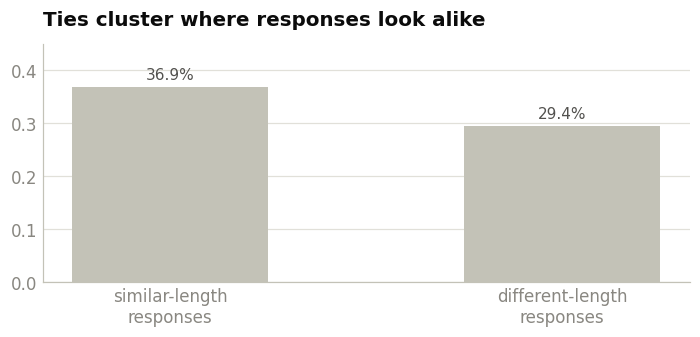

In [8]:
tr['similar_len'] = tr.len_ratio.abs() < 0.15
fig, ax = plt.subplots(figsize=(6.5, 3.2))
rates = [tr[tr.similar_len].target.eq('Tie').mean(), tr[~tr.similar_len].target.eq('Tie').mean()]
bars = ax.bar(['similar-length\nresponses', 'different-length\nresponses'], rates,
              color=GRAY, width=0.5)
ax.bar_label(bars, fmt='{:.1%}', padding=3, color=INK2, fontsize=10)
ax.set_ylim(0, 0.45)
finish(ax, 'Ties cluster where responses look alike')
plt.tight_layout(); plt.show()

Ties rise from 29% to **37%** when the answers are near-identical in length. Intuitive — and it
means our length features do double duty: their *magnitude* predicts a winner, their *absence*
predicts a tie.

<a id="trap"></a>
## 7. The trap: a great feature you can't use

The training data names the models. Model identity is *hugely* predictive:

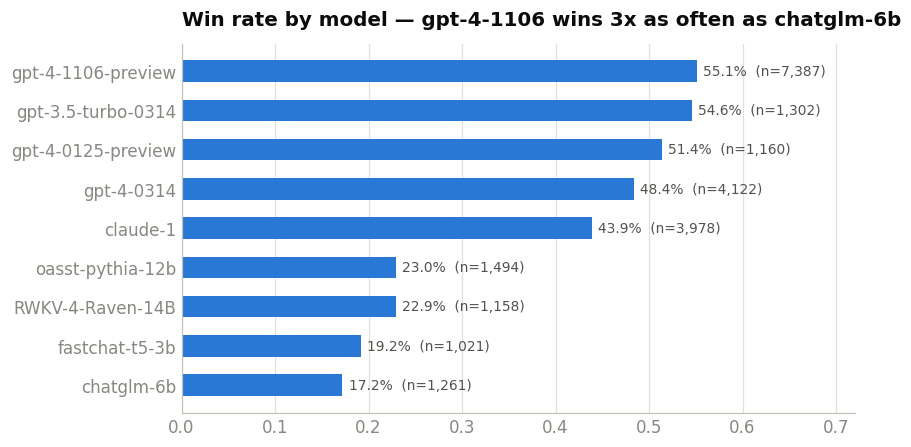

columns in test.csv: ['id', 'prompt', 'response_a', 'response_b', 'prompt_txt', 'response_a_txt', 'response_b_txt']


In [9]:
long_df = pd.concat([
    tr[['model_a', 'target']].rename(columns={'model_a': 'model'}).assign(win=lambda d: d.target == 'A wins'),
    tr[['model_b', 'target']].rename(columns={'model_b': 'model'}).assign(win=lambda d: d.target == 'B wins'),
])
g = long_df.groupby('model').agg(n=('win', 'size'), win_rate=('win', 'mean'))
g = g[g.n >= 1000].sort_values('win_rate')
show = pd.concat([g.head(4), g.tail(5)])

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(show.index, show.win_rate, color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f'{v:.1%}  (n={n:,})' for v, n in zip(show.win_rate, show.n)],
             padding=4, color=INK2, fontsize=9)
ax.set_xlim(0, 0.72)
finish(ax, 'Win rate by model — gpt-4-1106 wins 3x as often as chatglm-6b', ygrid=False)
plt.tight_layout(); plt.show()

print('columns in test.csv:', list(te.columns))

And here is the lesson every competition eventually teaches: **`model_a` and `model_b` do not exist
in the test set.** The strongest column in the training data is a mirage — build features on it and
your model learns a signal it will never see again. Check test-time availability *before* falling in
love with a feature.

(The subtler version of this trap: features that implicitly reconstruct model identity — like a
distinctive system-prompt phrase — generalize only as long as the same models appear at test time.)

<a id="features"></a>
## 8. From insights to features

Every bias above becomes a number the model can read. Nine engineered features, one per story beat,
plus TF-IDF for the content itself:

In [10]:
REFUSAL = re.compile(r"I cannot|I can't|I'm sorry|As an AI|I am unable|I apologize", re.I)
MD = re.compile(MD_PAT)

def feats(df):
    la = df.response_a_txt.str.len().to_numpy(float)
    lb = df.response_b_txt.str.len().to_numpy(float)
    return np.column_stack([
        np.log1p(la) - np.log1p(lb),                              # verbosity bias (section 3)
        np.log1p(la), np.log1p(lb),
        df.response_a_txt.str.count(MD).to_numpy(float),          # formatting (section 5)
        df.response_b_txt.str.count(MD).to_numpy(float),
        df.response_a_txt.str.count(REFUSAL).to_numpy(float),     # refusals (section 4)
        df.response_b_txt.str.count(REFUSAL).to_numpy(float),
        (np.abs(np.log1p(la) - np.log1p(lb)) < 0.15).astype(float),  # tie zone (section 6)
        df.prompt_txt.str.len().to_numpy(float) / 1000.0,
    ])

FEAT_NAMES = ['len ratio (A-B)', 'log len A', 'log len B', 'markdown A', 'markdown B',
              'refusals A', 'refusals B', 'similar length', 'prompt length']
Xf_tr, Xf_te = feats(tr), feats(te)
print('feature matrix:', Xf_tr.shape)

feature matrix: (57477, 9)


<a id="models"></a>
## 9. Models, honestly cross-validated

Log loss rewards **calibrated probabilities**, not bold calls — a confident wrong answer costs far
more than a humble one. Multinomial logistic regression is the natural fit: linear, fast, and its
probabilities are well-calibrated out of the box. We validate with 5-fold CV on the engineered
features and 3-fold on the heavier TF-IDF model (all preprocessing fitted inside each fold — no
leakage).

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

results = {}
prior = np.bincount(y) / len(y)
results['uniform guess'] = log_loss(y, np.tile([1/3]*3, (len(y), 1)))
results['class priors'] = log_loss(y, np.tile(prior, (len(y), 1)))

skf = StratifiedKFold(5, shuffle=True, random_state=42)
oof_f = np.zeros((len(y), 3))
for tr_i, va_i in skf.split(Xf_tr, y):
    sc = StandardScaler().fit(Xf_tr[tr_i])
    m = LogisticRegression(max_iter=2000).fit(sc.transform(Xf_tr[tr_i]), y[tr_i])
    oof_f[va_i] = m.predict_proba(sc.transform(Xf_tr[va_i]))
results['9 bias features'] = log_loss(y, oof_f)
print(f"bias features alone: {results['9 bias features']:.4f}")

sc_full = StandardScaler().fit(Xf_tr)
coef_model = LogisticRegression(max_iter=2000).fit(sc_full.transform(Xf_tr), y)

bias features alone: 1.0627


In [12]:
skf3 = StratifiedKFold(3, shuffle=True, random_state=42)
oof_t = np.zeros((len(y), 3))
for k, (tr_i, va_i) in enumerate(skf3.split(Xf_tr, y)):
    va_v = TfidfVectorizer(max_features=20000, min_df=5, sublinear_tf=True)
    vb_v = TfidfVectorizer(max_features=20000, min_df=5, sublinear_tf=True)
    Xa = va_v.fit_transform(tr.response_a_txt.iloc[tr_i]); Xa_v = va_v.transform(tr.response_a_txt.iloc[va_i])
    Xb = vb_v.fit_transform(tr.response_b_txt.iloc[tr_i]); Xb_v = vb_v.transform(tr.response_b_txt.iloc[va_i])
    sc = StandardScaler().fit(Xf_tr[tr_i])
    Xtr = hstack([Xa, Xb, csr_matrix(sc.transform(Xf_tr[tr_i]))]).tocsr()
    Xva = hstack([Xa_v, Xb_v, csr_matrix(sc.transform(Xf_tr[va_i]))]).tocsr()
    m = LogisticRegression(max_iter=800, C=0.5, solver='saga').fit(Xtr, y[tr_i])
    oof_t[va_i] = m.predict_proba(Xva)
    print(f'  fold {k}: {log_loss(y[va_i], oof_t[va_i]):.4f}', flush=True)
results['+ TF-IDF text'] = log_loss(y, oof_t)

best_w, best_ll = 0, 9
for w in np.arange(0.1, 0.6, 0.1):
    ll = log_loss(y, w * oof_f + (1 - w) * oof_t)
    if ll < best_ll:
        best_w, best_ll = w, ll
results['blend'] = best_ll
print(f"TF-IDF: {results['+ TF-IDF text']:.4f} | blend (w={best_w:.1f}): {best_ll:.4f}")

  fold 0: 1.0580
  fold 1: 1.0570
  fold 2: 1.0665
TF-IDF: 1.0605 | blend (w=0.5): 1.0457


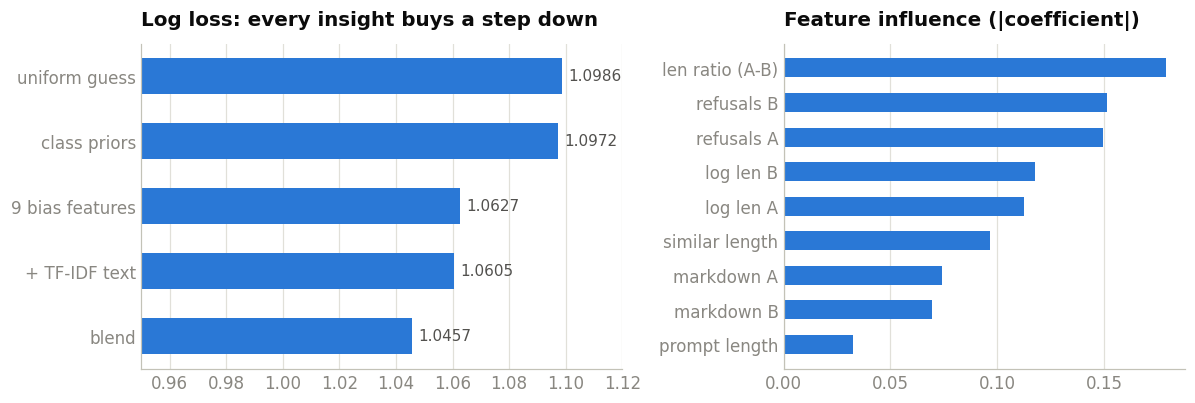

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1.2, 1]})
names = list(results)
vals = [results[n] for n in names]
bars = axes[0].barh(names[::-1], vals[::-1], color=BLUE, height=0.55)
axes[0].bar_label(bars, fmt='{:.4f}', padding=4, color=INK2, fontsize=10)
axes[0].set_xlim(0.95, 1.12)
finish(axes[0], 'Log loss: every insight buys a step down', ygrid=False)

order = np.argsort(np.abs(coef_model.coef_).max(0))
imp = np.abs(coef_model.coef_).max(0)[order]
axes[1].barh([FEAT_NAMES[i] for i in order], imp, color=BLUE, height=0.55)
finish(axes[1], 'Feature influence (|coefficient|)', ygrid=False)
plt.tight_layout(); plt.show()

The ladder tells the story in numbers: the nine bias features capture most of the easy signal in
six seconds of training; sixty thousand TF-IDF features add another chunk; blending the two models'
probabilities (they err differently) gives the best of both. The most influential features are
exactly the ones the EDA predicted: **length ratio and refusal counts.**

<a id="submission"></a>
## 10. Submission

Refit both models on all 57,477 battles, predict the test set, blend with the CV-chosen weight.

In [14]:
va_v = TfidfVectorizer(max_features=20000, min_df=5, sublinear_tf=True)
vb_v = TfidfVectorizer(max_features=20000, min_df=5, sublinear_tf=True)
Xa = va_v.fit_transform(tr.response_a_txt); Xa_te = va_v.transform(te.response_a_txt)
Xb = vb_v.fit_transform(tr.response_b_txt); Xb_te = vb_v.transform(te.response_b_txt)
sc = StandardScaler().fit(Xf_tr)
X_all = hstack([Xa, Xb, csr_matrix(sc.transform(Xf_tr))]).tocsr()
X_te = hstack([Xa_te, Xb_te, csr_matrix(sc.transform(Xf_te))]).tocsr()

m_t = LogisticRegression(max_iter=800, C=0.5, solver='saga').fit(X_all, y)
m_f = LogisticRegression(max_iter=2000).fit(sc.transform(Xf_tr), y)

P = best_w * m_f.predict_proba(sc.transform(Xf_te)) + (1 - best_w) * m_t.predict_proba(X_te)
sub = pd.DataFrame({'id': te['id'],
                    'winner_model_a': P[:, 0], 'winner_model_b': P[:, 1], 'winner_tie': P[:, 2]})
sub.to_csv('../results/predictions/reference_submission.csv', index=False)
print('submission.csv written'); sub.head()

submission.csv written


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.172497,0.327751,0.499752
1,211333,0.455164,0.299880,0.244956
2,1233961,0.274795,0.448112,0.277093


<a id="takeaways"></a>
## 11. Takeaways

- **Human preference is predictable — embarrassingly so.** Length, refusals, and formatting explain
  a large share of verdicts before reading a single word of content.
- **EDA is feature engineering.** All nine model features came directly from a chart in sections 3–6.
- **Check test-time availability first.** The strongest training column (model identity) doesn't
  exist at test time — the classic trap.
- **Log loss rewards humility.** A calibrated linear model beats an overconfident complex one here.
- **The road to the top:** fine-tune a DeBERTa/Gemma-style cross-encoder on (prompt, A, B) pairs with
  **position-swap augmentation** (feed each battle both as A-vs-B and B-vs-A to cancel position bias) —
  that's what winning solutions of the original LMSYS competition did, reaching ~0.88.

*Thanks for reading! Questions and corrections welcome in the comments — and if this helped,
an upvote is appreciated.*